In [1]:
import matplotlib.pyplot as plt
from sklearn.model_selection import KFold, cross_val_score
from sklearn.datasets import load_wine
from sklearn.tree import DecisionTreeClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC

In [2]:
wine = load_wine()
X = wine.data
y = wine.target

In [3]:
models = []
models.append(('NB', GaussianNB()))
models.append(('DT', DecisionTreeClassifier()))
models.append(('SVM', SVC()))
models.append(('KNN', KNeighborsClassifier()))
models.append(('RF', RandomForestClassifier()))

In [4]:
results = []
names = []

In [5]:
scoring = 'accuracy'
for name, model in models:
	kfold = KFold(n_splits=10, random_state=5,shuffle=True)
	cv_results = cross_val_score(model, X, y, cv=kfold, scoring=scoring)
	results.append(cv_results)
	names.append(name)
	msg = "%s: %f (%f)" % (name, cv_results.mean(), cv_results.std())
	print(msg)

NB: 0.972222 (0.037268)
DT: 0.881699 (0.078005)
SVM: 0.685948 (0.081286)
KNN: 0.697712 (0.076505)
RF: 0.977451 (0.027631)


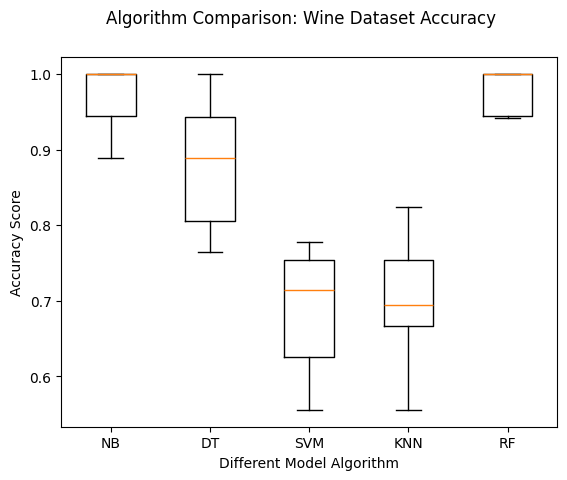

In [6]:
fig = plt.figure()
fig.suptitle('Algorithm Comparison: Wine Dataset Accuracy')
ax = fig.add_subplot(111)
plt.boxplot(results)
ax.set_xticklabels(names)
plt.ylabel('Accuracy Score')
plt.xlabel('Different Model Algorithm')
plt.show()